In [2]:
#Khởi chạy các thư viện
#pip install ta vnstock yfinance lightgbm xgboost

In [3]:
#thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vnstock import Vnstock
import yfinance as yf
import ta

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time

In [4]:
#tắt cảnh báo
import warnings
warnings.filterwarnings('ignore')

In [5]:
#Thiết lập các dữ liệu trong dataframe chỉ hiện 3 số sau dấu phẩy
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Lấy dữ liệu vnstock

In [ ]:
stock = Vnstock().stock(symbol='VCI', source='VCI')

In [ ]:
#Chỉ số VNIndex
VNIndex_historical_data=stock.quote.history(symbol='VNINDEX', start='2015-01-01', end='2025-04-01', interval='1D')
# Đặt cột 'time' làm cột index
VNIndex_historical_data.set_index('time', inplace=True)
VNIndex_historical_data

,open,high,low,close,volume
time,,,,,
2015-01-05,544.860,549.220,543.780,544.450,95949953
2015-01-06,539.080,550.110,538.820,549.660,112316461
2015-01-07,548.440,555.830,548.440,552.050,111705080
2015-01-08,553.490,556.800,552.150,553.470,77867146
2015-01-09,553.490,570.520,552.150,569.730,107474507
...,...,...,...,...,...
2025-03-26,1333.610,1338.550,1323.690,1326.090,817278760
2025-03-27,1326.210,1328.820,1323.010,1323.810,670218049
2025-03-28,1324.420,1325.340,1315.720,1317.460,732006432


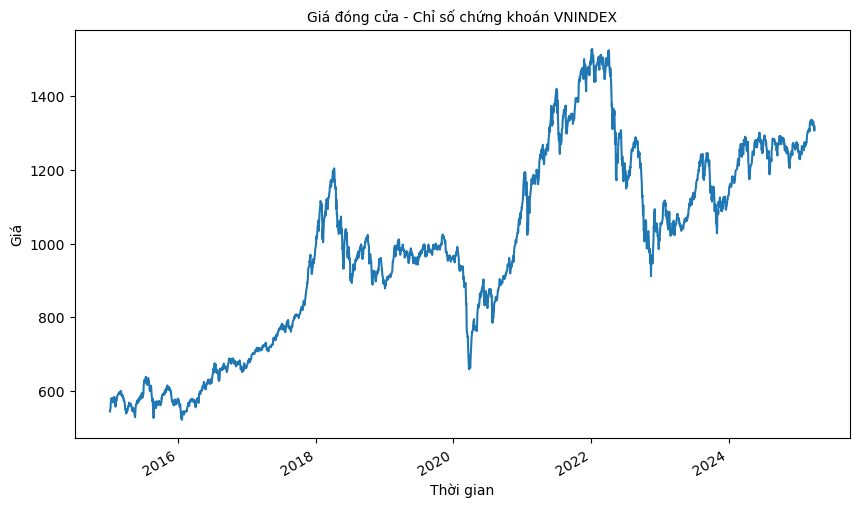

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Giá đóng cửa - Chỉ số chứng khoán VNINDEX'}, xlabel='Thời gian', ylabel='Giá'>)

In [ ]:
VNIndex_historical_data['close'].viz.timeseries(figsize=(10, 6), 
                           title='Giá đóng cửa - Chỉ số chứng khoán VNINDEX', 
                           ylabel='Giá', 
                           xlabel='Thời gian',
                           color_palette='vnstock',
                           palette_shuffle=True)

# Dữ liệu vĩ mô

### Tỷ giá USD/VND

In [ ]:
#Tỷ giá (đơn vị VND)
# Lấy dữ liệu USD/VND (Yahoo Finance có mã là 'VND=X')
usd_vnd = yf.download("VND=X", start="2015-01-01", end="2025-04-02", interval="1d")
usd_vnd.columns = usd_vnd.columns.set_levels(
    ['USD/VND' if level == 'VND=X' else level for level in usd_vnd.columns.levels[1]],
    level='Ticker')

usd_vnd

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VND=X']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,USD/VND,USD/VND,USD/VND,USD/VND,USD/VND,USD/VND
Date,,,,,,


### Giá vàng

In [ ]:
#Giá vàng (đơn vị USD)
gold = yf.download("GC=F", start="2015-01-01", end="2025-04-02", interval="1d")
gold.columns = gold.columns.set_levels(
    ['Gold' if level == 'GC=F' else level for level in gold.columns.levels[1]],
    level='Ticker')
gold

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,Gold,Gold,Gold,Gold,Gold
Date,,,,,
2015-01-02,1186.000,1194.500,1169.500,1184.000,138
2015-01-05,1203.900,1206.900,1180.100,1180.300,470
2015-01-06,1219.300,1220.000,1203.500,1203.500,97
2015-01-07,1210.600,1219.200,1210.600,1219.200,29
2015-01-08,1208.400,1215.700,1206.300,1207.000,92
...,...,...,...,...,...
2025-03-26,3020.900,3033.200,3019.500,3033.200,83
2025-03-27,3060.200,3065.000,3025.500,3025.500,124359


### Giá dầu

In [ ]:
#Giá dầu (đơn vị USD)
symbol = "CL=F"  # WTI

# Lấy dữ liệu từ 2020-01-01 đến 2025-04-01
petro_price = yf.download(symbol, start="2015-01-01", end="2025-04-02")

petro_price.columns = petro_price.columns.set_levels(
    ['Oil' if level == 'CL=F' else level for level in petro_price.columns.levels[1]],
    level='Ticker')

# Hiển thị dữ liệu
petro_price

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['CL=F']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,Oil,Oil,Oil,Oil,Oil,Oil
Date,,,,,,


### S&P 500

In [ ]:
import yfinance as yf

# Ticker S&P 500
sp500 = yf.download('^GSPC', start="2015-01-01",  end="2025-04-02", interval='1d', progress=True)

sp500.columns = sp500.columns.set_levels(
    ['S&P500' if level == '^GSPC' else level for level in sp500.columns.levels[1]], level='Ticker')

# Hiển thị
sp500

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,S&P500,S&P500,S&P500,S&P500,S&P500,S&P500
Date,,,,,,


# Gộp dữ liệu thô

In [ ]:
raw=pd.concat([VNIndex_historical_data, usd_vnd, gold, petro_price, sp500], axis=1, sort=True)
raw

,open,high,low,close,volume,"(Close, USD/VND)","(High, USD/VND)","(Low, USD/VND)","(Open, USD/VND)","(Volume, USD/VND)",...,"(Close, Oil)","(High, Oil)","(Low, Oil)","(Open, Oil)","(Volume, Oil)","(Close, S&P500)","(High, S&P500)","(Low, S&P500)","(Open, S&P500)","(Volume, S&P500)"
2015-01-01,NaN,NaN,NaN,NaN,NaN,21375.000,21375.000,21156.000,21157.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,NaN,NaN,NaN,NaN,NaN,21063.000,21214.000,21063.000,21214.000,0.000,...,52.690,55.110,52.030,53.760,268708.000,2058.200,2072.360,2046.040,2058.900,2708700000.000
2015-01-05,544.860,549.220,543.780,544.450,95949953.000,21046.000,21375.000,21046.000,21219.000,0.000,...,50.040,52.730,49.680,52.610,375782.000,2020.580,2054.440,2017.340,2054.440,3799120000.000
2015-01-06,539.080,550.110,538.820,549.660,112316461.000,21097.000,21390.000,20987.000,20987.000,0.000,...,47.930,50.370,47.550,50.000,451642.000,2002.610,2030.250,1992.440,2022.150,4460110000.000
2015-01-07,548.440,555.830,548.440,552.050,111705080.000,21083.000,21415.000,21083.000,21135.000,0.000,...,48.650,49.310,46.830,48.000,460083.000,2025.900,2029.610,2005.550,2005.550,3805480000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1333.610,1338.550,1323.690,1326.090,817278760.000,25600.000,25630.000,25550.000,25600.000,0.000,...,69.650,70.220,69.060,69.160,262413.000,5712.200,5783.620,5694.410,5771.660,4183140000.000
2025-03-27,1326.210,1328.820,1323.010,1323.810,670218049.000,25555.000,25610.000,25550.000,25555.000,0.000,...,69.920,69.970,69.120,69.960,211825.000,5693.310,5732.280,5670.940,5695.640,4403460000.000
2025-03-28,1324.420,1325.340,1315.720,1317.460,732006432.000,25560.000,25580.000,25540.000,25560.000,0.000,...,69.360,70.090,68.870,69.910,246650.000,5580.940,5685.890,5572.420,5679.200,4513330000.000
2025-03-31,1313.340,1314.090,1304.100,1306.860,863075434.000,25550.000,25575.000,25530.000,25550.000,0.000,...,71.480,71.830,68.810,69.430,313087.000,5611.850,5627.560,5488.730,5527.910,5257250000.000


In [ ]:
# Đổi tên cột 
raw = raw.rename(columns={
    '(Close, USD/VND)': 'USD/VND',
    '(Close, Gold)': 'Gold',
    '(Close, SP500)': 'SP500',
    '(Close, Oil)': 'Oil'
})
# Xóa cột 
raw = raw.drop(columns=[
    "(High, USD/VND)", "(Low, USD/VND)", "(Open, USD/VND)", "(Volume, USD/VND)",
    "(High, Gold)", "(Low, Gold)", "(Open, Gold)", "(Volume, Gold)",
    "(High, Oil)", "(Low, Oil)", "(Open, Oil)", "(Volume, Oil)",
    "(High, SP500)", "(Low, SP500)", "(Open, SP500)", "(Volume, SP500)"
])

In [ ]:
# with pd.ExcelWriter("VNINDEX-Forecasting-Data.xlsx", engine="openpyxl") as writer:
#     raw.to_excel(writer, sheet_name="Dữ liệu thô", index=True)

# Chỉ báo kỹ thuật

In [19]:
raw_data = pd.read_excel("VNINDEX-Forecasting-Data.xlsx", sheet_name="Dữ liệu thô", index_col=0)
raw_data = raw_data.dropna()

raw_data.head()

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500
2015-01-05,544.860,549.220,543.780,544.450,95949953.000,21046.000,1203.900,50.040,2020.580
2015-01-06,539.080,550.110,538.820,549.660,112316461.000,21097.000,1219.300,47.930,2002.610
2015-01-07,548.440,555.830,548.440,552.050,111705080.000,21083.000,1210.600,48.650,2025.900
2015-01-08,553.490,556.800,552.150,553.470,77867146.000,21061.000,1208.400,48.790,2062.140
2015-01-09,553.490,570.520,552.150,569.730,107474507.000,21021.000,1216.000,48.360,2044.810


In [20]:
#thủ công
# Tính ROC (Rate of Change)
def calculate_roc(df, n=14):
    df['roc'] = ((df['close'] - df['close'].shift(n)) / df['close'].shift(n)) * 100
    return df

# Tính CCI (Commodity Channel Index)
def calculate_cci(df, n=20):
    df['typical_price'] = (df['high'] + df['low'] + df['close']) / 3
    df['sma'] = df['typical_price'].rolling(window=n).mean()
    df['mad'] = df['typical_price'].rolling(window=n).apply(lambda x: np.fabs(x - x.mean()).mean(), raw=True)
    df['cci'] = (df['typical_price'] - df['sma']) / (0.015 * df['mad'])
    return df

# Tính RSI (Relative Strength Index)
def calculate_rsi(df, n=14):
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=n).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=n).mean()

    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    return df

# Tính MACD (Moving Average Convergence Divergence)
def calculate_macd(df, fast=12, slow=26, signal=9):
    df['ema_fast'] = df['close'].ewm(span=fast, adjust=False).mean()
    df['ema_slow'] = df['close'].ewm(span=slow, adjust=False).mean()
    df['macd'] = df['ema_fast'] - df['ema_slow']
    df['macd_signal'] = df['macd'].ewm(span=signal, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    return df

# Tính OBV (On-balance Volume)
def calculate_obv(df):
    df['obv'] = np.where(df['close'] > df['close'].shift(1), df['volume'], 
                         np.where(df['close'] < df['close'].shift(1), -df['volume'], 0))
    df['obv'] = df['obv'].cumsum()  # Tích lũy OBV
    return df

indicators = raw_data.copy()

# Áp dụng các hàm tính toán
indicators = calculate_roc(indicators)
indicators = calculate_cci(indicators)
indicators = calculate_rsi(indicators)
indicators = calculate_macd(indicators)
indicators = calculate_obv(indicators)

# Xem kết quả
indicators

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500,roc,typical_price,sma,mad,cci,rsi,ema_fast,ema_slow,macd,macd_signal,macd_hist,obv
2015-01-05,544.860,549.220,543.780,544.450,95949953.000,21046.000,1203.900,50.040,2020.580,NaN,545.817,NaN,NaN,NaN,NaN,544.450,544.450,0.000,0.000,0.000,0.000
2015-01-06,539.080,550.110,538.820,549.660,112316461.000,21097.000,1219.300,47.930,2002.610,NaN,546.197,NaN,NaN,NaN,NaN,545.252,544.836,0.416,0.083,0.332,112316461.000
2015-01-07,548.440,555.830,548.440,552.050,111705080.000,21083.000,1210.600,48.650,2025.900,NaN,552.107,NaN,NaN,NaN,NaN,546.297,545.370,0.927,0.252,0.675,224021541.000
2015-01-08,553.490,556.800,552.150,553.470,77867146.000,21061.000,1208.400,48.790,2062.140,NaN,554.140,NaN,NaN,NaN,NaN,547.401,545.970,1.431,0.488,0.943,301888687.000
2015-01-09,553.490,570.520,552.150,569.730,107474507.000,21021.000,1216.000,48.360,2044.810,NaN,564.133,NaN,NaN,NaN,NaN,550.836,547.730,3.106,1.011,2.095,409363194.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1333.610,1338.550,1323.690,1326.090,817278760.000,25600.000,3020.900,69.650,5712.200,0.597,1329.443,1322.733,8.754,51.104,56.072,1325.597,1314.758,10.839,12.852,-2.013,104797824218.000
2025-03-27,1326.210,1328.820,1323.010,1323.810,670218049.000,25555.000,3060.200,69.920,5693.310,-0.169,1325.213,1323.792,7.519,12.601,48.110,1325.322,1315.428,9.894,12.261,-2.367,104127606169.000
2025-03-28,1324.420,1325.340,1315.720,1317.460,732006432.000,25560.000,3086.500,69.360,5580.940,-0.964,1319.507,1324.521,6.593,-50.700,39.557,1324.112,1315.579,8.534,11.515,-2.982,103395599737.000
2025-03-31,1313.340,1314.090,1304.100,1306.860,863075434.000,25550.000,3122.800,71.480,5611.850,-1.927,1308.350,1324.548,6.561,-164.580,31.583,1321.458,1314.933,6.525,10.517,-3.992,102532524303.000


In [21]:
# Xóa cột 
data = indicators.drop(columns=['typical_price', 'sma', 'ema_fast', 'ema_slow', 'mad', 'macd_hist'])

In [ ]:
#Hoàn chỉnh dữ liệu để đưa vào mô hình
#with pd.ExcelWriter("VNINDEX-Forecasting-Data.xlsx", mode='a', engine='openpyxl') as writer: data.to_excel(writer, sheet_name="Biến")

# Mô hình học máy

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
raw_data = pd.read_excel("VNINDEX-Forecasting-Data.xlsx", sheet_name="Dữ liệu thô", index_col=0)
raw_data = raw_data.dropna()

raw_data

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500
2015-01-05,544.860,549.220,543.780,544.450,95949953.000,21046.000,1203.900,50.040,2020.580
2015-01-06,539.080,550.110,538.820,549.660,112316461.000,21097.000,1219.300,47.930,2002.610
2015-01-07,548.440,555.830,548.440,552.050,111705080.000,21083.000,1210.600,48.650,2025.900
2015-01-08,553.490,556.800,552.150,553.470,77867146.000,21061.000,1208.400,48.790,2062.140
2015-01-09,553.490,570.520,552.150,569.730,107474507.000,21021.000,1216.000,48.360,2044.810
...,...,...,...,...,...,...,...,...,...
2025-03-26,1333.610,1338.550,1323.690,1326.090,817278760.000,25600.000,3020.900,69.650,5712.200
2025-03-27,1326.210,1328.820,1323.010,1323.810,670218049.000,25555.000,3060.200,69.920,5693.310
2025-03-28,1324.420,1325.340,1315.720,1317.460,732006432.000,25560.000,3086.500,69.360,5580.940
2025-03-31,1313.340,1314.090,1304.100,1306.860,863075434.000,25550.000,3122.800,71.480,5611.850


In [8]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2473 entries, 2015-01-05 to 2025-04-01
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   open     2473 non-null   float64
 1   high     2473 non-null   float64
 2   low      2473 non-null   float64
 3   close    2473 non-null   float64
 4   volume   2473 non-null   float64
 5   USD/VND  2473 non-null   float64
 6   Gold     2473 non-null   float64
 7   Oil      2473 non-null   float64
 8   SP500    2473 non-null   float64
dtypes: float64(9)
memory usage: 193.2 KB


In [9]:
# Tạo bảng thống kê mô tả
raw_data.describe()

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500
count,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000
mean,984.932,990.892,978.135,984.851,405774797.384,23115.712,1633.679,62.209,3416.994
std,262.410,263.837,260.093,262.031,314565684.461,1022.032,434.508,17.982,1136.747
min,511.130,525.830,511.130,521.880,61680945.000,20922.000,1050.800,-37.630,1859.330
25%,766.140,769.360,761.640,766.840,139235599.000,22385.000,1265.600,48.650,2443.250
50%,986.520,992.000,982.640,987.360,235672860.000,23128.000,1575.100,60.520,3078.270
75%,1208.220,1217.840,1198.680,1209.520,648766800.000,23444.000,1889.800,73.890,4283.850
max,1534.100,1536.450,1524.960,1528.570,1708947942.000,25620.000,3122.800,123.700,6144.150


In [10]:
data = pd.read_excel("VNINDEX-Forecasting-Data.xlsx", sheet_name="Biến", index_col=0)
data = data.dropna()
data

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500,roc,cci,rsi,macd,macd_signal,obv
2015-01-30,584.080,584.080,574.460,576.070,102197700.000,21074.000,1278.500,48.240,1994.990,0.305,49.508,51.781,7.928,7.937,340659756.000
2015-02-02,576.070,579.730,570.370,570.370,85071802.000,20991.000,1276.200,49.570,2020.850,-1.762,7.807,39.464,6.874,7.724,255587954.000
2015-02-03,572.560,574.830,557.470,557.470,96961011.000,20973.000,1259.700,53.050,2050.030,-3.386,-105.771,33.114,4.940,7.167,158626943.000
2015-02-04,556.930,561.690,553.210,561.450,100169716.000,21058.000,1263.800,48.450,2041.510,-2.820,-165.415,36.672,3.687,6.471,258796659.000
2015-02-05,562.170,568.220,562.050,567.170,78742544.000,20979.000,1262.000,50.480,2062.520,-1.329,-105.566,44.022,3.119,5.801,337539203.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1333.610,1338.550,1323.690,1326.090,817278760.000,25600.000,3020.900,69.650,5712.200,0.597,51.104,56.072,10.752,12.745,109923873422.000
2025-03-27,1326.210,1328.820,1323.010,1323.810,670218049.000,25555.000,3060.200,69.920,5693.310,-0.169,12.601,48.110,9.813,12.159,109253655373.000
2025-03-28,1324.420,1325.340,1315.720,1317.460,732006432.000,25560.000,3086.500,69.360,5580.940,-0.964,-50.700,39.557,8.458,11.419,108521648941.000
2025-03-31,1313.340,1314.090,1304.100,1306.860,863075434.000,25550.000,3122.800,71.480,5611.850,-1.927,-164.580,31.583,6.454,10.426,107658573507.000


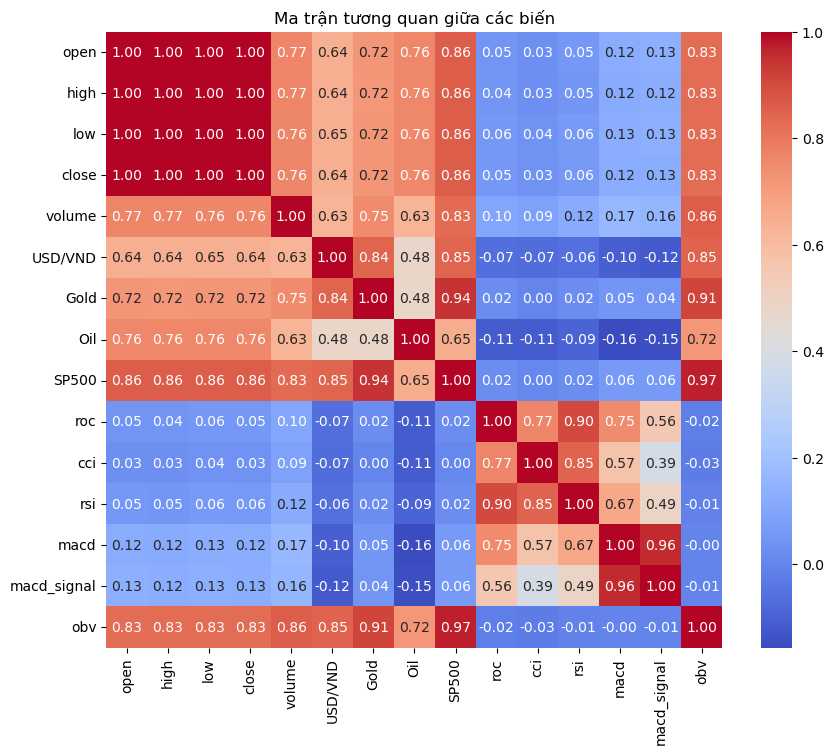

In [11]:
# Tính ma trận tương quan
corr_matrix = data.corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', square=True)
plt.title("Ma trận tương quan giữa các biến")
plt.show()

In [12]:
#loại bỏ các biến có tương quan cao
data_filtered = data.drop(columns=['open', 'high', 'low', 'macd_signal','obv'])

In [13]:
# Danh sách các cột cần tạo biến lag
cols_to_lag = ["close","volume","USD/VND", "Gold", "Oil", "SP500", "roc", "cci", "rsi", "macd"]
lags = [1,2,3,4,5]

data_lag = data_filtered.copy()

# Tạo biến lag cho từng cột và từng độ trễ
for col in cols_to_lag:
    for lag in lags:
        data_lag[f"{col}_lag{lag}"] = data_lag[col].shift(lag)

# Xoá các dòng chứa NaN sau khi tạo lag
data_lag = data_lag.dropna()#.reset_index(drop=True)
data_lag

,close,volume,USD/VND,Gold,Oil,SP500,roc,cci,rsi,macd,close_lag1,close_lag2,close_lag3,close_lag4,close_lag5,volume_lag1,volume_lag2,volume_lag3,volume_lag4,volume_lag5,USD/VND_lag1,USD/VND_lag2,USD/VND_lag3,USD/VND_lag4,USD/VND_lag5,Gold_lag1,Gold_lag2,Gold_lag3,Gold_lag4,Gold_lag5,Oil_lag1,Oil_lag2,Oil_lag3,Oil_lag4,Oil_lag5,SP500_lag1,SP500_lag2,SP500_lag3,SP500_lag4,SP500_lag5,roc_lag1,roc_lag2,roc_lag3,roc_lag4,roc_lag5,cci_lag1,cci_lag2,cci_lag3,cci_lag4,cci_lag5,rsi_lag1,rsi_lag2,rsi_lag3,rsi_lag4,rsi_lag5,macd_lag1,macd_lag2,macd_lag3,macd_lag4,macd_lag5
2015-02-06,574.130,64274918.000,20978.000,1233.900,51.690,2055.470,0.458,-30.813,51.939,3.194,567.170,561.450,557.470,570.370,576.070,78742544.000,100169716.000,96961011.000,85071802.000,102197700.000,20979.000,21058.000,20973.000,20991.000,21074.000,1262.000,1263.800,1259.700,1276.200,1278.500,50.480,48.450,53.050,49.570,48.240,2062.520,2041.510,2050.030,2020.850,1994.990,-1.329,-2.820,-3.386,-1.762,0.305,-105.566,-165.415,-105.771,7.807,49.508,44.022,36.672,33.114,39.464,51.781,3.119,3.687,4.940,6.874,7.928
2015-02-09,573.550,71316820.000,20961.000,1240.800,52.860,2046.740,0.232,-8.329,50.986,3.169,574.130,567.170,561.450,557.470,570.370,64274918.000,78742544.000,100169716.000,96961011.000,85071802.000,20978.000,20979.000,21058.000,20973.000,20991.000,1233.900,1262.000,1263.800,1259.700,1276.200,51.690,50.480,48.450,53.050,49.570,2055.470,2062.520,2041.510,2050.030,2020.850,0.458,-1.329,-2.820,-3.386,-1.762,-30.813,-105.566,-165.415,-105.771,7.807,51.939,44.022,36.672,33.114,39.464,3.194,3.119,3.687,4.940,6.874
2015-02-10,574.520,73830792.000,20970.000,1231.600,50.020,2068.590,0.949,16.044,54.135,3.192,573.550,574.130,567.170,561.450,557.470,71316820.000,64274918.000,78742544.000,100169716.000,96961011.000,20961.000,20978.000,20979.000,21058.000,20973.000,1240.800,1233.900,1262.000,1263.800,1259.700,52.860,51.690,50.480,48.450,53.050,2046.740,2055.470,2062.520,2041.510,2050.030,0.232,0.458,-1.329,-2.820,-3.386,-8.329,-30.813,-105.566,-165.415,-105.771,50.986,51.939,44.022,36.672,33.114,3.169,3.194,3.119,3.687,4.940
2015-02-11,581.760,77500496.000,20968.000,1219.000,48.840,2068.530,1.257,64.599,55.378,3.750,574.520,573.550,574.130,567.170,561.450,73830792.000,71316820.000,64274918.000,78742544.000,100169716.000,20970.000,20961.000,20978.000,20979.000,21058.000,1231.600,1240.800,1233.900,1262.000,1263.800,50.020,52.860,51.690,50.480,48.450,2068.590,2046.740,2055.470,2062.520,2041.510,0.949,0.232,0.458,-1.329,-2.820,16.044,-8.329,-30.813,-105.566,-165.415,54.135,50.986,51.939,44.022,36.672,3.192,3.169,3.194,3.119,3.687
2015-02-12,584.670,82989180.000,20943.000,1220.100,51.210,2088.480,0.393,113.363,51.841,4.378,581.760,574.520,573.550,574.130,567.170,77500496.000,73830792.000,71316820.000,64274918.000,78742544.000,20968.000,20970.000,20961.000,20978.000,20979.000,1219.000,1231.600,1240.800,1233.900,1262.000,48.840,50.020,52.860,51.690,50.480,2068.530,2068.590,2046.740,2055.470,2062.520,1.257,0.949,0.232,0.458,-1.329,64.599,16.044,-8.329,-30.813,-105.566,55.378,54.135,50.986,51.939,44.022,3.750,3.192,3.169,3.194,3.119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1326.090,817278760.000,25600.000,3020.900,69.650,5712.200,0.597,51.104,56.072,10.752,1331.920,1330.320,1321.880,1323.930,1324.630,1006767919.000,917944680.000,799888919.000,910926478.000,945849600.000,25620.000,25585.000,25545.000,25535.000,25510.000,3023.700,3013.100,3018.200,3040.000,3035.900,69.000,69.110,68.280,68.260,67.160,5776.650,5767.570,5667.560,5662.890,5675.290,2.086,1.403,0.955,1.423,1.287,79.795,37.485,23.044,37.364,49.856,68.768,61.788,58.665,62.522,61.088,11.564,11.837,12.177,13.293,14.316
2025-03-27,1323.810,670218049.000,25555.000,3060.200,69.920,5693.310,-0.169,12.601,48.110,9.813,1326.09

In [14]:
data_lag = data_lag.drop(columns=["volume","USD/VND", "Gold", "Oil", "SP500", "roc", "cci", "rsi", "macd"])
data_lag

,close,close_lag1,close_lag2,close_lag3,close_lag4,close_lag5,volume_lag1,volume_lag2,volume_lag3,volume_lag4,volume_lag5,USD/VND_lag1,USD/VND_lag2,USD/VND_lag3,USD/VND_lag4,USD/VND_lag5,Gold_lag1,Gold_lag2,Gold_lag3,Gold_lag4,Gold_lag5,Oil_lag1,Oil_lag2,Oil_lag3,Oil_lag4,Oil_lag5,SP500_lag1,SP500_lag2,SP500_lag3,SP500_lag4,SP500_lag5,roc_lag1,roc_lag2,roc_lag3,roc_lag4,roc_lag5,cci_lag1,cci_lag2,cci_lag3,cci_lag4,cci_lag5,rsi_lag1,rsi_lag2,rsi_lag3,rsi_lag4,rsi_lag5,macd_lag1,macd_lag2,macd_lag3,macd_lag4,macd_lag5
2015-02-06,574.130,567.170,561.450,557.470,570.370,576.070,78742544.000,100169716.000,96961011.000,85071802.000,102197700.000,20979.000,21058.000,20973.000,20991.000,21074.000,1262.000,1263.800,1259.700,1276.200,1278.500,50.480,48.450,53.050,49.570,48.240,2062.520,2041.510,2050.030,2020.850,1994.990,-1.329,-2.820,-3.386,-1.762,0.305,-105.566,-165.415,-105.771,7.807,49.508,44.022,36.672,33.114,39.464,51.781,3.119,3.687,4.940,6.874,7.928
2015-02-09,573.550,574.130,567.170,561.450,557.470,570.370,64274918.000,78742544.000,100169716.000,96961011.000,85071802.000,20978.000,20979.000,21058.000,20973.000,20991.000,1233.900,1262.000,1263.800,1259.700,1276.200,51.690,50.480,48.450,53.050,49.570,2055.470,2062.520,2041.510,2050.030,2020.850,0.458,-1.329,-2.820,-3.386,-1.762,-30.813,-105.566,-165.415,-105.771,7.807,51.939,44.022,36.672,33.114,39.464,3.194,3.119,3.687,4.940,6.874
2015-02-10,574.520,573.550,574.130,567.170,561.450,557.470,71316820.000,64274918.000,78742544.000,100169716.000,96961011.000,20961.000,20978.000,20979.000,21058.000,20973.000,1240.800,1233.900,1262.000,1263.800,1259.700,52.860,51.690,50.480,48.450,53.050,2046.740,2055.470,2062.520,2041.510,2050.030,0.232,0.458,-1.329,-2.820,-3.386,-8.329,-30.813,-105.566,-165.415,-105.771,50.986,51.939,44.022,36.672,33.114,3.169,3.194,3.119,3.687,4.940
2015-02-11,581.760,574.520,573.550,574.130,567.170,561.450,73830792.000,71316820.000,64274918.000,78742544.000,100169716.000,20970.000,20961.000,20978.000,20979.000,21058.000,1231.600,1240.800,1233.900,1262.000,1263.800,50.020,52.860,51.690,50.480,48.450,2068.590,2046.740,2055.470,2062.520,2041.510,0.949,0.232,0.458,-1.329,-2.820,16.044,-8.329,-30.813,-105.566,-165.415,54.135,50.986,51.939,44.022,36.672,3.192,3.169,3.194,3.119,3.687
2015-02-12,584.670,581.760,574.520,573.550,574.130,567.170,77500496.000,73830792.000,71316820.000,64274918.000,78742544.000,20968.000,20970.000,20961.000,20978.000,20979.000,1219.000,1231.600,1240.800,1233.900,1262.000,48.840,50.020,52.860,51.690,50.480,2068.530,2068.590,2046.740,2055.470,2062.520,1.257,0.949,0.232,0.458,-1.329,64.599,16.044,-8.329,-30.813,-105.566,55.378,54.135,50.986,51.939,44.022,3.750,3.192,3.169,3.194,3.119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1326.090,1331.920,1330.320,1321.880,1323.930,1324.630,1006767919.000,917944680.000,799888919.000,910926478.000,945849600.000,25620.000,25585.000,25545.000,25535.000,25510.000,3023.700,3013.100,3018.200,3040.000,3035.900,69.000,69.110,68.280,68.260,67.160,5776.650,5767.570,5667.560,5662.890,5675.290,2.086,1.403,0.955,1.423,1.287,79.795,37.485,23.044,37.364,49.856,68.768,61.788,58.665,62.522,61.088,11.564,11.837,12.177,13.293,14.316
2025-03-27,1323.810,1326.090,1331.920,1330.320,1321.880,1323.930,817278760.000,1006767919.000,917944680.000,799888919.000,910926478.000,25600.000,25620.000,25585.000,25545.000,25535.000,3020.900,3023.700,3013.100,3018.200,3040.000,69.650,69.000,69.110,68.280,68.260,5712.200,5776.650,5767.570,5667.560,5662.890,0.597,2.086,1.403,0.955,1.423,51.104,79.795,37.485,23.044,37.364,56.072,68.768,61.788,58.665,62.522,10.752,11.564,11.837,12.177,13.293
2025-03-28,1317.460,1323.810,1326.090,1331.920,1330.320,1321.880,670218049.000,817278760.000,1006767919.000,917944680.000,799888919.000,25555.000,25600.000,25620.000,25585.000,25545.000,30

In [15]:
# Tách features và target
X = data_lag.drop(columns=["close"])   # Dữ liệu đầu vào
y = data_lag["close"]                  # Biến mục tiêu

# Chia tập huấn luyện và kiểm tra (80/20) theo thời gian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [16]:
# Kiểm tra số lượng quan sát
print(f"Số quan sát tập huấn luyện: {X_train.shape[0]}")
print(f"Số quan sát tập kiểm tra: {X_test.shape[0]}")

Số quan sát tập huấn luyện: 1960
Số quan sát tập kiểm tra: 490


In [17]:
# Kiểm tra khoảng thời gian của mỗi tập
print(f"Khoảng thời gian tập huấn luyện: {X_train.index[0]} đến {X_train.index[-1]}")
print(f"Khoảng thời gian tập kiểm tra: {X_test.index[0]} đến {X_test.index[-1]}")

Khoảng thời gian tập huấn luyện: 2015-02-06 00:00:00 đến 2023-03-21 00:00:00
Khoảng thời gian tập kiểm tra: 2023-03-22 00:00:00 đến 2025-04-01 00:00:00


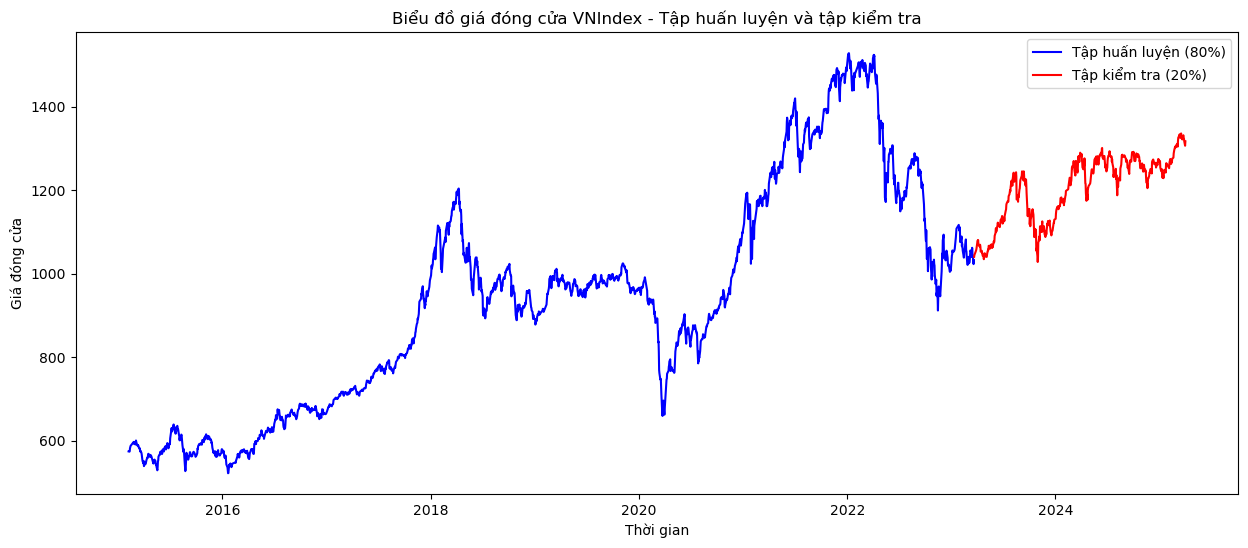

In [18]:
# Vẽ biểu đồ giá đóng cửa cho cả hai tập
plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train, label='Tập huấn luyện (80%)', color='blue')
plt.plot(y_test.index, y_test, label='Tập kiểm tra (20%)', color='red')
plt.xlabel('Thời gian')
plt.ylabel('Giá đóng cửa')
plt.title('Biểu đồ giá đóng cửa VNIndex - Tập huấn luyện và tập kiểm tra')
plt.legend()
plt.show()

In [18]:
# Chuẩn hóa
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# Áp dụng scaler đã fit cho tập kiểm tra
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Sau khi chuẩn hóa, chuyển lại thành DataFrame có cột kiểu chuỗi
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns.astype(str), index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns.astype(str), index=X_test.index)

### LinearRegression

In [19]:
model_LR = LinearRegression()

In [20]:
model_LR.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [21]:
# Dự đoán trên tập huấn luyện và kiểm tra
y_train_pred_LR = model_LR.predict(X_train_scaled)
y_test_pred_LR = model_LR.predict(X_test_scaled)

#Đảo ngược chuẩn hóa
y_train_pred_LR = scaler_y.inverse_transform(y_train_pred_LR)
y_test_pred_LR = scaler_y.inverse_transform(y_test_pred_LR)

# --- Train metrics ---
mse_train_LR = mean_squared_error(y_train, y_train_pred_LR)
rmse_train_LR = np.sqrt(mse_train_LR)
mae_train_LR = mean_absolute_error(y_train, y_train_pred_LR)
r2_train_LR = r2_score(y_train, y_train_pred_LR)

# --- Test metrics ---
mse_test_LR = mean_squared_error(y_test, y_test_pred_LR)
rmse_test_LR = np.sqrt(mse_test_LR)
mae_test_LR = mean_absolute_error(y_test, y_test_pred_LR)
r2_test_LR = r2_score(y_test, y_test_pred_LR)

# In kết quả
print("---- Train Metrics ----")
print(f"MSE: {mse_train_LR:.3f}")
print(f"RMSE: {rmse_train_LR:.3f}")
print(f"MAE: {mae_train_LR:.3f}")
print(f"R2: {r2_train_LR:.3f}")

print("\n---- Test Metrics ----")
print(f"MSE: {mse_test_LR:.3f}")
print(f"RMSE: {rmse_test_LR:.3f}")
print(f"MAE: {mae_test_LR:.3f}")
print(f"R2: {r2_test_LR:.3f}")

---- Train Metrics ----
MSE: 133.769
RMSE: 11.566
MAE: 7.716
R2: 0.998

---- Test Metrics ----
MSE: 123.448
RMSE: 11.111
MAE: 8.158
R2: 0.981


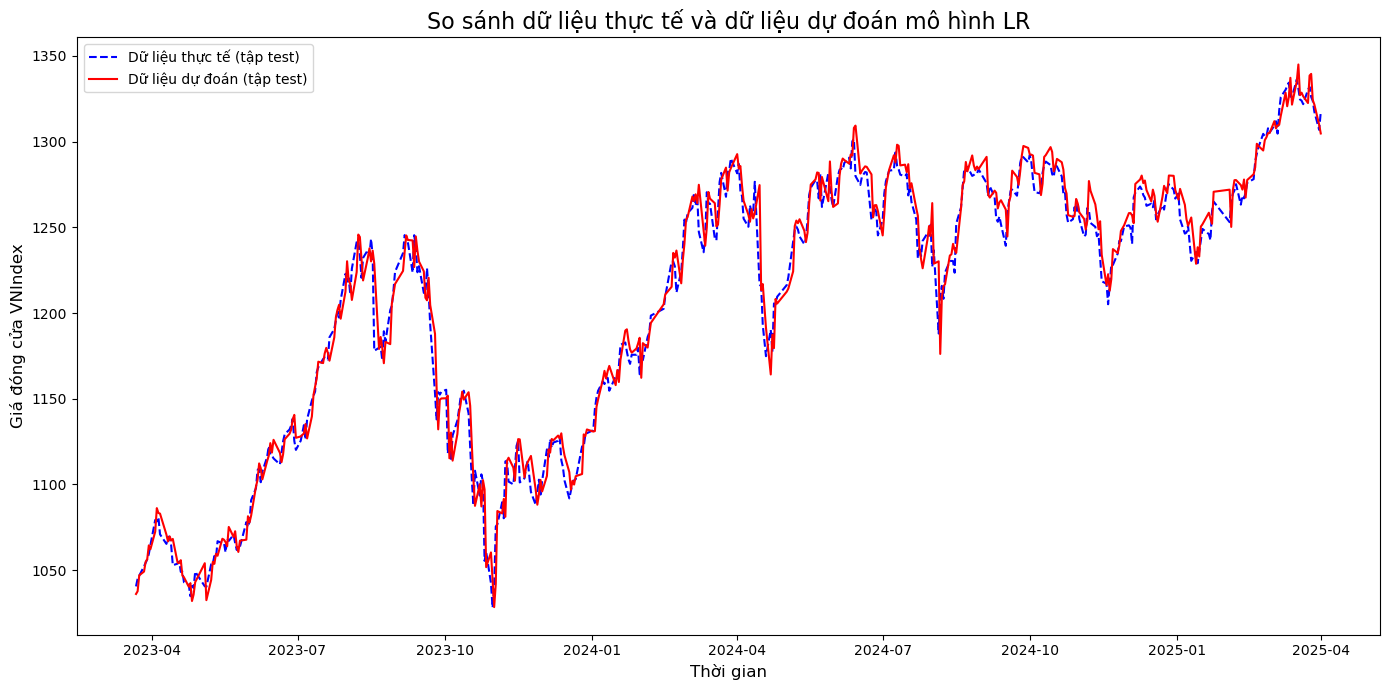

In [22]:
# Vẽ biểu đồ
plt.figure(figsize=(14,7))

# Vẽ dữ liệu thực tế
plt.plot(y_test.index, y_test, color='blue', label='Dữ liệu thực tế (tập test)', linestyle='--')

# Vẽ dự đoán từ mô hình
plt.plot(y_test.index, y_test_pred_LR, color='red', label='Dữ liệu dự đoán (tập test)', linestyle='-')

# Thêm nhãn và tiêu đề
plt.title("So sánh dữ liệu thực tế và dữ liệu dự đoán mô hình LR", fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá đóng cửa VNIndex', fontsize=12)

# Định dạng lại trục x để dễ đọc (có thể cần điều chỉnh tùy theo số lượng ngày)
plt.xticks()

# Thêm legend
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


### SVR

In [23]:
# Tập siêu tham số cần tìm
param_grid_svr = {
    'kernel': ['rbf', 'linear', 'poly'],       # loại kernel
    'C': [0.1, 1, 10, 100],                    # hệ số điều chỉnh độ phạt
    'epsilon': [0.01, 0.1, 0.2],               # sai số chấp nhận trong hàm mất mát
    'gamma': ['scale', 'auto']                # hệ số kernel 
}

# GridSearchCV
svr = SVR()
grid_svr = GridSearchCV(estimator=svr, param_grid=param_grid_svr,
                        cv=5, n_jobs=-1, scoring='neg_mean_squared_error', verbose=1)

# Huấn luyện mô hình
grid_svr.fit(X_train_scaled, y_train_scaled)

# Kết quả tốt nhất
print("Tham số SVR tốt nhất:", grid_svr.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

In [24]:
model_SVR = SVR(C=1, epsilon=0.01, gamma='scale', kernel='linear')

In [25]:
model_SVR.fit(X_train_scaled, y_train_scaled)

SVR(C=1, epsilon=0.01, kernel='linear')

In [26]:
# Dự đoán trên tập huấn luyện và kiểm tra
y_train_pred_SVR = model_SVR.predict(X_train_scaled)
y_test_pred_SVR = model_SVR.predict(X_test_scaled)

#Đảo ngược chuẩn hóa
y_train_pred_SVR = scaler_y.inverse_transform(y_train_pred_SVR.reshape(-1, 1))
y_test_pred_SVR = scaler_y.inverse_transform(y_test_pred_SVR.reshape(-1, 1))

# --- Train metrics ---
mse_train_SVR = mean_squared_error(y_train, y_train_pred_SVR)
rmse_train_SVR = np.sqrt(mse_train_SVR)
mae_train_SVR = mean_absolute_error(y_train, y_train_pred_SVR)
r2_train_SVR = r2_score(y_train, y_train_pred_SVR)

# --- Test metrics ---
mse_test_SVR = mean_squared_error(y_test, y_test_pred_SVR)
rmse_test_SVR = np.sqrt(mse_test_SVR)
mae_test_SVR = mean_absolute_error(y_test, y_test_pred_SVR)
r2_test_SVR = r2_score(y_test, y_test_pred_SVR)

# In kết quả
print("---- Train Metrics ----")
print(f"MSE: {mse_train_SVR:.3f}")
print(f"RMSE: {rmse_train_SVR:.3f}")
print(f"MAE: {mae_train_SVR:.3f}")
print(f"R2: {r2_train_SVR:.3f}")

print("\n---- Test Metrics ----")
print(f"MSE: {mse_test_SVR:.3f}")
print(f"RMSE: {rmse_test_SVR:.3f}")
print(f"MAE: {mae_test_SVR:.3f}")
print(f"R2: {r2_test_SVR:.3f}")

---- Train Metrics ----
MSE: 139.055
RMSE: 11.792
MAE: 7.920
R2: 0.998

---- Test Metrics ----
MSE: 129.585
RMSE: 11.384
MAE: 8.460
R2: 0.980


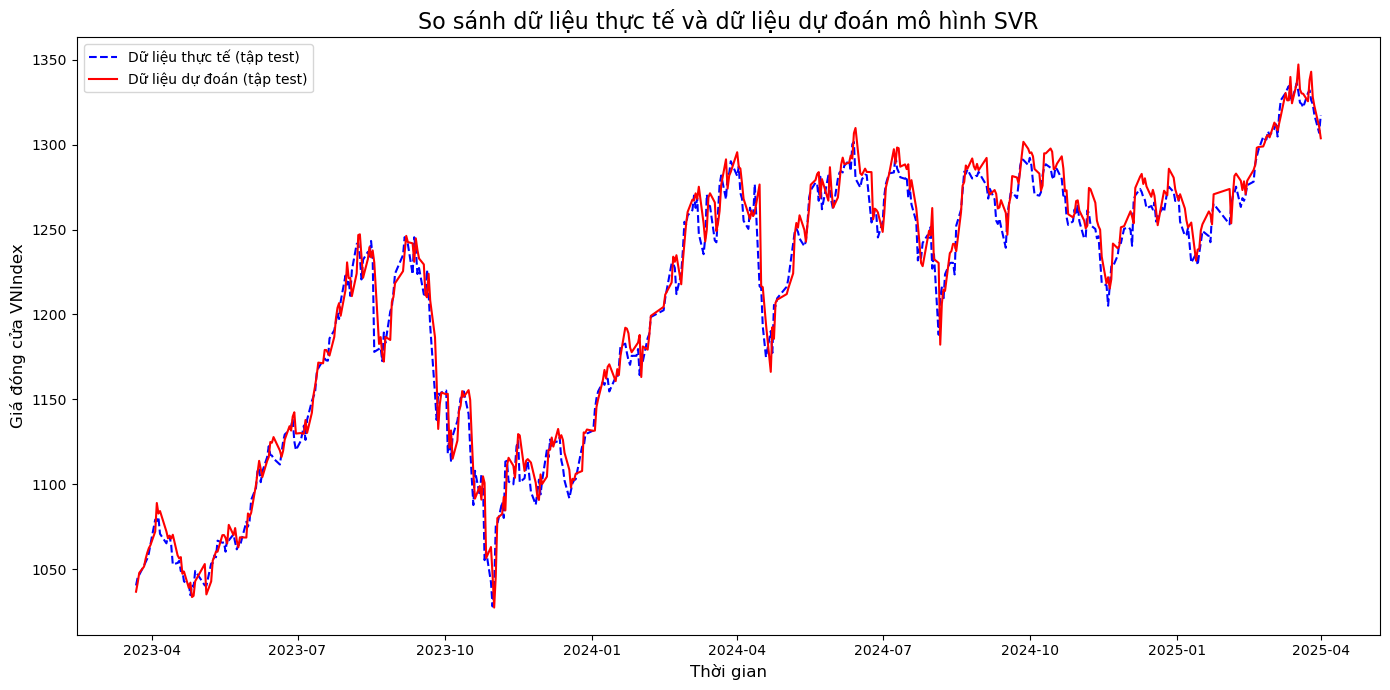

In [28]:
# Vẽ biểu đồ
plt.figure(figsize=(14,7))

# Vẽ dữ liệu thực tế
plt.plot(y_test.index, y_test, color='blue', label='Dữ liệu thực tế (tập test)', linestyle='--')

# Vẽ dự đoán từ mô hình
plt.plot(y_test.index, y_test_pred_SVR, color='red', label='Dữ liệu dự đoán (tập test)', linestyle='-')

# Thêm nhãn và tiêu đề
plt.title("So sánh dữ liệu thực tế và dữ liệu dự đoán mô hình SVR", fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá đóng cửa VNIndex', fontsize=12)

# Định dạng lại trục x để dễ đọc (có thể cần điều chỉnh tùy theo số lượng ngày)
plt.xticks()

# Thêm legend
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


### RF

In [91]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=1)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train_scaled)

print("Tham số RF tốt nhất:", grid_rf.best_params_)

Best RF Params: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Score (MSE): 0.002442785116110359


In [29]:
model_RF = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=2, random_state=1)

In [30]:
model_RF.fit(X_train_scaled, y_train_scaled)

RandomForestRegressor(max_depth=5, min_samples_leaf=2, random_state=1)

In [31]:
# Dự đoán trên tập huấn luyện và kiểm tra
y_train_pred_RF = model_RF.predict(X_train_scaled)
y_test_pred_RF = model_RF.predict(X_test_scaled)

#Đảo ngược chuẩn hóa
y_train_pred_RF = scaler_y.inverse_transform(y_train_pred_RF.reshape(-1, 1))
y_test_pred_RF = scaler_y.inverse_transform(y_test_pred_RF.reshape(-1, 1))

# --- Train metrics ---
mse_train_RF = mean_squared_error(y_train, y_train_pred_RF)
rmse_train_RF = np.sqrt(mse_train_RF)
mae_train_RF = mean_absolute_error(y_train, y_train_pred_RF)
r2_train_RF = r2_score(y_train, y_train_pred_RF)

# --- Test metrics ---
mse_test_RF = mean_squared_error(y_test, y_test_pred_RF)
rmse_test_RF = np.sqrt(mse_test_RF)
mae_test_RF = mean_absolute_error(y_test, y_test_pred_RF)
r2_test_RF = r2_score(y_test, y_test_pred_RF)

# In kết quả
print("---- Train Metrics ----")
print(f"MSE: {mse_train_RF:.3f}")
print(f"RMSE: {rmse_train_RF:.3f}")
print(f"MAE: {mae_train_RF:.3f}")
print(f"R2: {r2_train_RF:.3f}")

print("\n---- Test Metrics ----")
print(f"MSE: {mse_test_RF:.3f}")
print(f"RMSE: {rmse_test_RF:.3f}")
print(f"MAE: {mae_test_RF:.3f}")
print(f"R2: {r2_test_RF:.3f}")

---- Train Metrics ----
MSE: 133.672
RMSE: 11.562
MAE: 8.008
R2: 0.998

---- Test Metrics ----
MSE: 169.931
RMSE: 13.036
MAE: 9.687
R2: 0.973


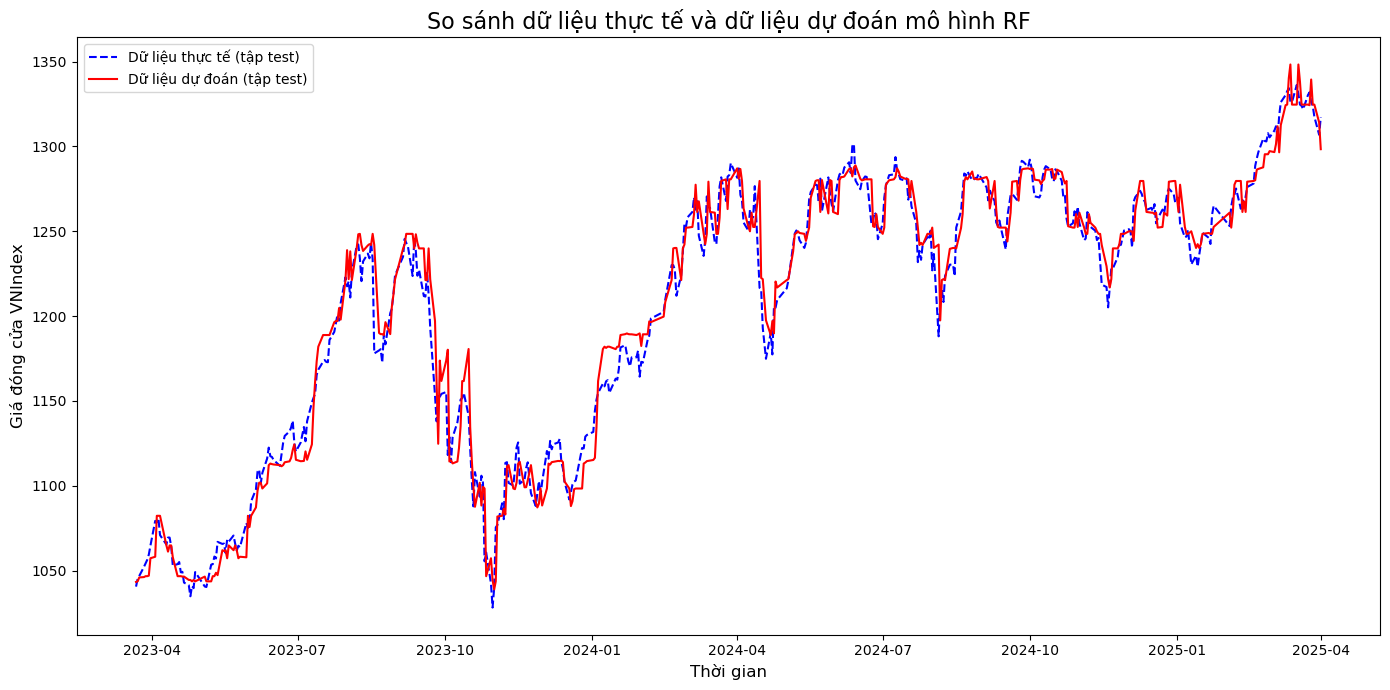

In [33]:
# Vẽ biểu đồ
plt.figure(figsize=(14,7))

# Vẽ dữ liệu thực tế
plt.plot(y_test.index, y_test, color='blue', label='Dữ liệu thực tế (tập test)', linestyle='--')

# Vẽ dự đoán từ mô hình
plt.plot(y_test.index, y_test_pred_RF, color='red', label='Dữ liệu dự đoán (tập test)', linestyle='-')

# Thêm nhãn và tiêu đề
plt.title("So sánh dữ liệu thực tế và dữ liệu dự đoán mô hình RF", fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá đóng cửa VNIndex', fontsize=12)

# Định dạng lại trục x để dễ đọc (có thể cần điều chỉnh tùy theo số lượng ngày)
plt.xticks()

# Thêm legend
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


### XGBoost

In [92]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],           # số cây
    'max_depth': [3, 5, 7],                    # độ sâu mỗi cây
    'learning_rate': [0.01, 0.05, 0.1],        # tốc độ học
    'subsample': [0.6, 0.8, 1.0],              # tỷ lệ mẫu dùng để huấn luyện mỗi cây
    'colsample_bytree': [0.6, 0.8, 1.0],       # tỷ lệ cột được chọn cho mỗi cây
    'reg_alpha': [0, 1, 2],                    # regularization L1
    'reg_lambda': [0, 1, 2]                    # regularization L2
}

xgb = xgb.XGBRegressor(random_state=1, objective='reg:squarederror')
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_scaled)

print("Tham số XGB tốt nhất:", grid_xgb.best_params_)

Best XGB Params: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.6}
Best XGB Score (MSE): 0.00231808390721563


In [75]:
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=1,
    reg_lambda=0,
    random_state=1
)

In [76]:
model_xgb.fit(X_train_scaled, y_train_scaled)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [77]:
# Dự đoán trên tập huấn luyện và kiểm tra
y_train_pred_xgb = model_xgb.predict(X_train_scaled)
y_test_pred_xgb = model_xgb.predict(X_test_scaled)

#Đảo ngược chuẩn hóa
y_train_pred_xgb = scaler_y.inverse_transform(y_train_pred_xgb.reshape(-1, 1))
y_test_pred_xgb = scaler_y.inverse_transform(y_test_pred_xgb.reshape(-1, 1))

# --- Train metrics ---
mse_train_xgb = mean_squared_error(y_train, y_train_pred_xgb)
rmse_train_xgb = np.sqrt(mse_train_xgb)
mae_train_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)

# --- Test metrics ---
mse_test_xgb = mean_squared_error(y_test, y_test_pred_xgb)
rmse_test_xgb = np.sqrt(mse_test_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

# In kết quả
print("---- Train Metrics ----")
print(f"MSE: {mse_train_xgb:.3f}")
print(f"RMSE: {rmse_train_xgb:.3f}")
print(f"MAE: {mae_train_xgb:.3f}")
print(f"R2: {r2_train_xgb:.3f}")

print("\n---- Test Metrics ----")
print(f"MSE: {mse_test_xgb:.3f}")
print(f"RMSE: {rmse_test_xgb:.3f}")
print(f"MAE: {mae_test_xgb:.3f}")
print(f"R2: {r2_test_xgb:.3f}")

---- Train Metrics ----
MSE: 131.443
RMSE: 11.465
MAE: 7.786
R2: 0.998

---- Test Metrics ----
MSE: 138.318
RMSE: 11.761
MAE: 8.697
R2: 0.978


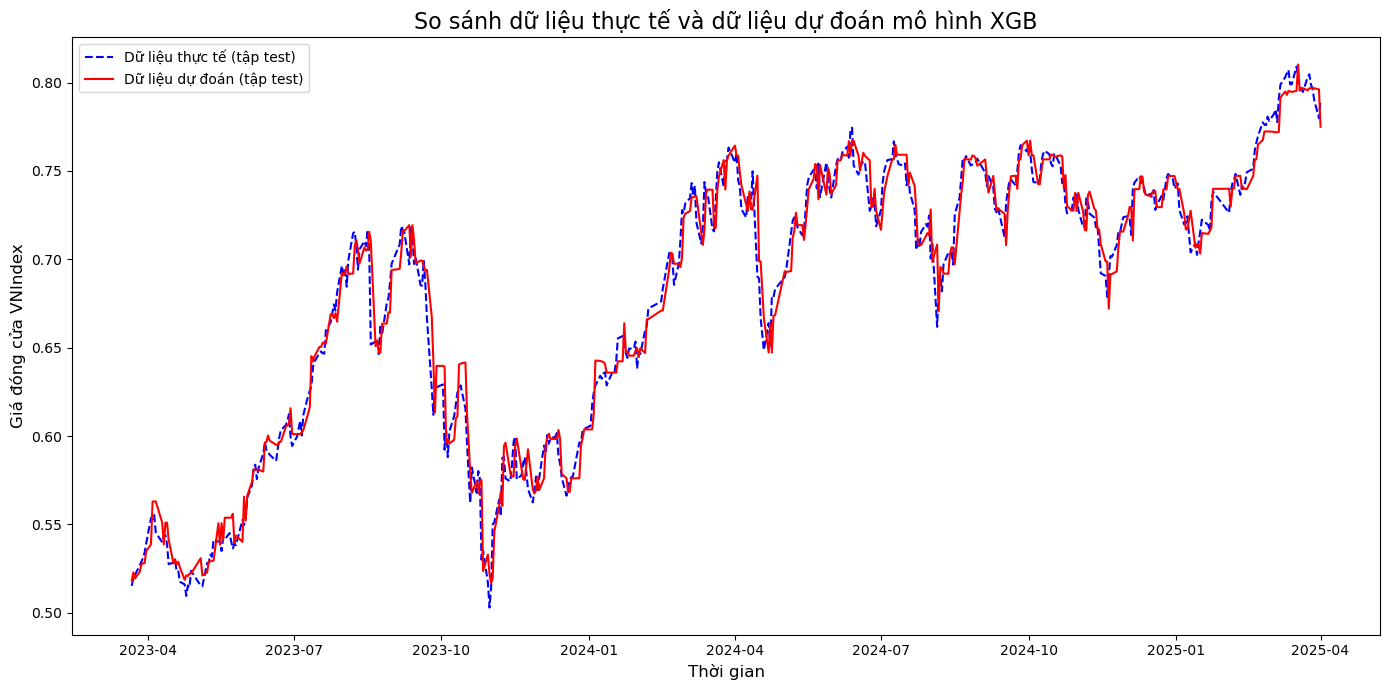

In [60]:
# Vẽ biểu đồ
plt.figure(figsize=(14,7))

# Vẽ dữ liệu thực tế
plt.plot(y_test.index, y_test, color='blue', label='Dữ liệu thực tế (tập test)', linestyle='--')

# Vẽ dự đoán từ mô hình
plt.plot(y_test.index, y_test_pred_xgb, color='red', label='Dữ liệu dự đoán (tập test)', linestyle='-')

# Thêm nhãn và tiêu đề
plt.title("So sánh dữ liệu thực tế và dữ liệu dự đoán mô hình XGB", fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá đóng cửa VNIndex', fontsize=12)

# Định dạng lại trục x để dễ đọc (có thể cần điều chỉnh tùy theo số lượng ngày)
plt.xticks()

# Thêm legend
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


### LightGBM

In [93]:
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],                    
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 1, 2],
    'reg_lambda': [0, 1, 2]
}
lgb = lgb.LGBMRegressor(random_state=1)
grid_lgb = GridSearchCV(lgb, param_grid_lgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lgb.fit(X_train_scaled, y_train_scaled)

print("Tham số LGBM tốt nhất:", grid_lgb.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000982 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 1960, number of used features: 50
[LightGBM] [Info] Start training from score 0.410084
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [58]:
param_grid_lgb = {
    'n_estimators': [100],
    'max_depth': [3],                    
    'learning_rate': [0.1],
    'subsample': [1.0],
    'colsample_bytree': [1.0],
    'reg_alpha': [1],
    'reg_lambda': [1]
}
lgb = lgb.LGBMRegressor(random_state=1)
grid_lgb = GridSearchCV(lgb, param_grid_lgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lgb.fit(X_train_scaled, y_train_scaled)

print("Tham số LGBM tốt nhất:", grid_lgb.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 1960, number of used features: 50
[LightGBM] [Info] Start training from score 0.410084
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [78]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=1, 
    reg_lambda=1,
    random_state=1)

In [79]:
model_lgb.fit(X_train_scaled, y_train_scaled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000484 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 1960, number of used features: 50
[LightGBM] [Info] Start training from score 0.410084
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(max_depth=3, random_state=1, reg_alpha=1, reg_lambda=1)

In [80]:
# Dự đoán trên tập huấn luyện và kiểm tra
y_train_pred_lgb = model_lgb.predict(X_train_scaled)
y_test_pred_lgb = model_lgb.predict(X_test_scaled)

#Đảo ngược chuẩn hóa
y_train_pred_lgb = scaler_y.inverse_transform(y_train_pred_lgb.reshape(-1, 1))
y_test_pred_lgb = scaler_y.inverse_transform(y_test_pred_lgb.reshape(-1, 1))

# --- Train metrics ---
mse_train_lgb = mean_squared_error(y_train, y_train_pred_lgb)
rmse_train_lgb = np.sqrt(mse_train_lgb)
mae_train_lgb = mean_absolute_error(y_train, y_train_pred_lgb)
r2_train_lgb = r2_score(y_train, y_train_pred_lgb)

# --- Test metrics ---
mse_test_lgb = mean_squared_error(y_test, y_test_pred_lgb)
rmse_test_lgb = np.sqrt(mse_test_lgb)
mae_test_lgb = mean_absolute_error(y_test, y_test_pred_lgb)
r2_test_lgb = r2_score(y_test, y_test_pred_lgb)

# In kết quả
print("---- Train Metrics ----")
print(f"MSE: {mse_train_lgb:.3f}")
print(f"RMSE: {rmse_train_lgb:.3f}")
print(f"MAE: {mae_train_lgb:.3f}")
print(f"R2: {r2_train_lgb:.3f}")

print("\n---- Test Metrics ----")
print(f"MSE: {mse_test_lgb:.3f}")
print(f"RMSE: {rmse_test_lgb:.3f}")
print(f"MAE: {mae_test_lgb:.3f}")
print(f"R2: {r2_test_lgb:.3f}")

---- Train Metrics ----
MSE: 139.498
RMSE: 11.811
MAE: 7.937
R2: 0.998

---- Test Metrics ----
MSE: 133.732
RMSE: 11.564
MAE: 8.503
R2: 0.979


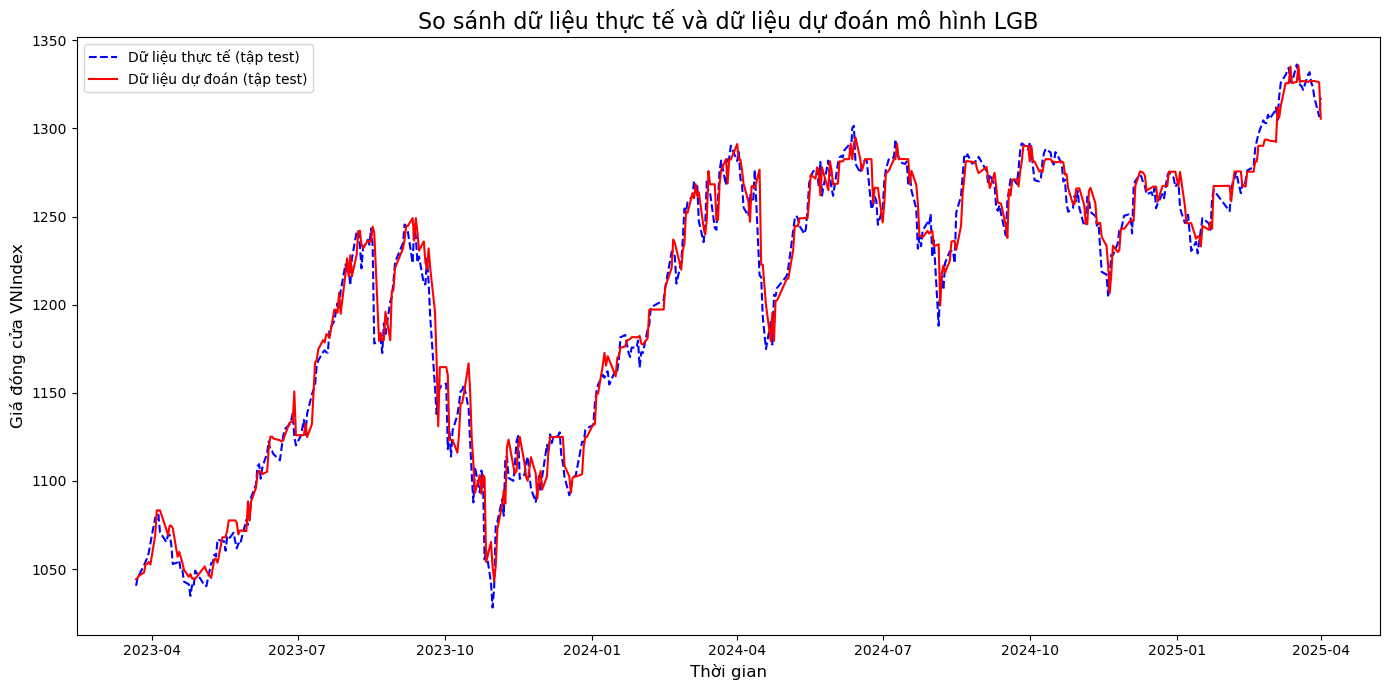

In [45]:
# Vẽ biểu đồ
plt.figure(figsize=(14,7))

# Vẽ dữ liệu thực tế
plt.plot(y_test.index, y_test, color='blue', label='Dữ liệu thực tế (tập test)', linestyle='--')

# Vẽ dự đoán từ mô hình
plt.plot(y_test.index, y_test_pred_lgb, color='red', label='Dữ liệu dự đoán (tập test)', linestyle='-')

# Thêm nhãn và tiêu đề
plt.title("So sánh dữ liệu thực tế và dữ liệu dự đoán mô hình LGB", fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá đóng cửa VNIndex', fontsize=12)

# Định dạng lại trục x để dễ đọc (có thể cần điều chỉnh tùy theo số lượng ngày)
plt.xticks()

# Thêm legend
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


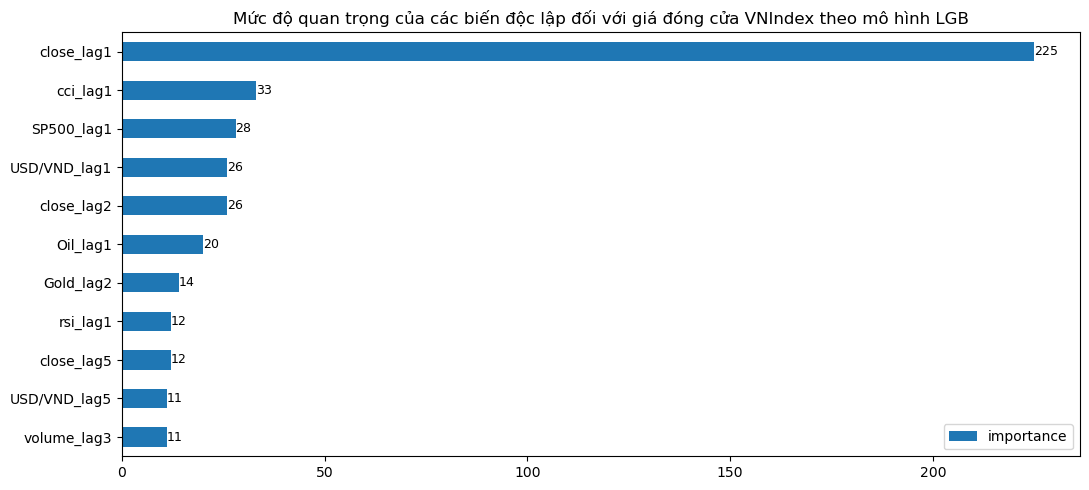

In [66]:
fi=pd.DataFrame(data=model_lgb.feature_importances_,
             index=model_lgb.feature_names_in_,
             columns=['importance'])

fi_filtered = fi[fi['importance'] > 10]  # chỉ hiện thị các biến có độ quan trọng trên 10

# Vẽ biểu đồ
ax = fi_filtered.sort_values('importance').plot(kind='barh', title='Mức độ quan trọng của các biến độc lập đối với giá đóng cửa VNIndex theo mô hình LGB', figsize=(11, 5))

# Thêm số cụ thể tại mỗi thanh
for i, v in enumerate(fi_filtered.sort_values('importance')['importance']):
    ax.text(v, i, f"{v}", va='center', fontsize=9)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

### Biểu đồ so sánh dữ liệu thực tế và dự đoán của 5 mô hình

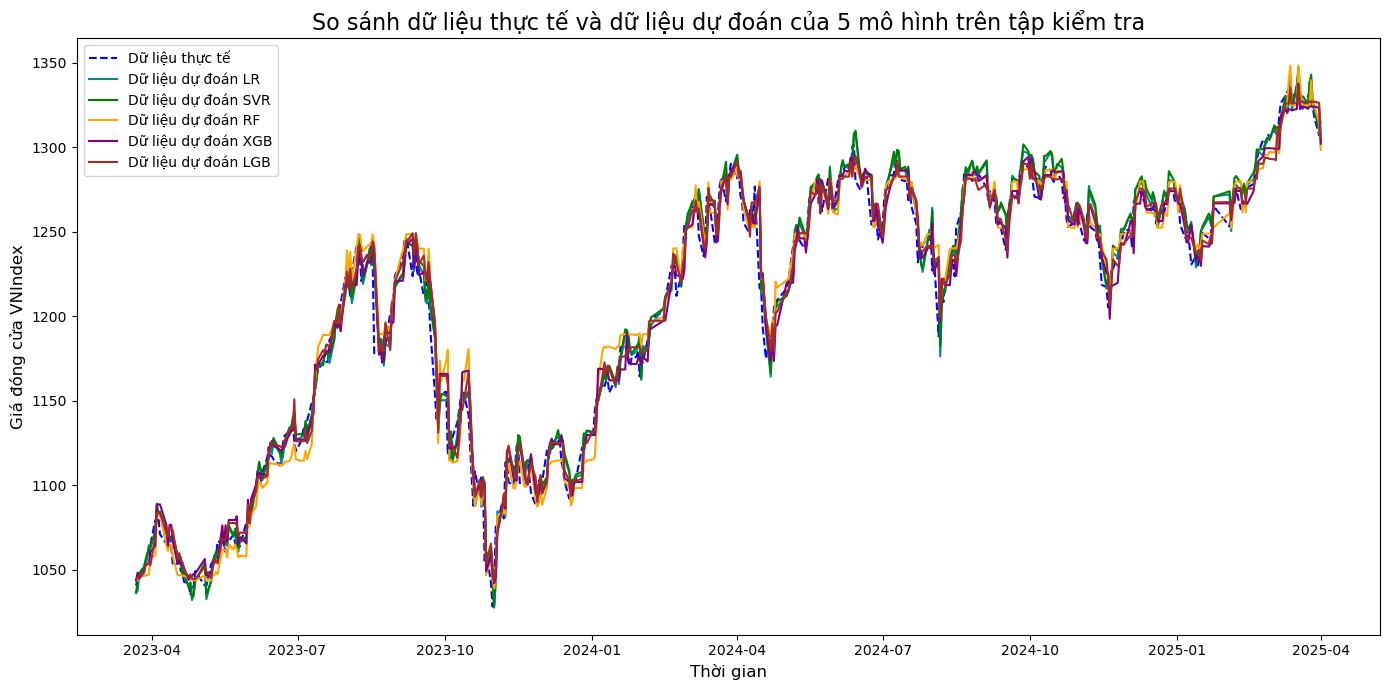

In [46]:
# Vẽ biểu đồ
plt.figure(figsize=(14,7))

# Vẽ dữ liệu thực tế
plt.plot(y_test.index, y_test, color='blue', label='Dữ liệu thực tế', linestyle='--')

# Vẽ dự đoán từ 5 mô hình
plt.plot(y_test.index, y_test_pred_LR, color='darkcyan', label='Dữ liệu dự đoán LR', linestyle='-')
plt.plot(y_test.index, y_test_pred_SVR, color='green', label='Dữ liệu dự đoán SVR', linestyle='-')
plt.plot(y_test.index, y_test_pred_RF, color='orange', label='Dữ liệu dự đoán RF', linestyle='-')
plt.plot(y_test.index, y_test_pred_xgb, color='purple', label='Dữ liệu dự đoán XGB', linestyle='-')
plt.plot(y_test.index, y_test_pred_lgb, color='brown', label='Dữ liệu dự đoán LGB', linestyle='-')

# Thêm nhãn và tiêu đề
plt.title("So sánh dữ liệu thực tế và dữ liệu dự đoán của 5 mô hình trên tập kiểm tra", fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá đóng cửa VNIndex', fontsize=12)

# Định dạng lại trục x để dễ đọc 
plt.xticks()

# Thêm legend
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## Dự báo đa bước

In [19]:
df = data_lag.copy()

# Chia dữ liệu 
size = int(len(df) * 0.95)
df_train = df.iloc[:size]
df_test = df.iloc[size:]

In [42]:
max_forecast_horizon = len(df_test)
start = time.time()

# Tập biến đầu vào (lag features)
X_cols = [col for col in df_train.columns if '_lag' in col]

# Huấn luyện từng mô hình dự báo trực tiếp cho từng bước trong test set
models = {}
predictions = pd.DataFrame()

for step in range(1, max_forecast_horizon + 1):
    df_data = df_train.copy()
    df_data[f'target_t+{step}'] = df_data['close'].shift(-step)
    df_data.dropna(inplace=True)
    
    X = df_data[X_cols]
    y = df_data[f'target_t+{step}']

    # Chuẩn hóa
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

    #model = LinearRegression()

    #model = SVR(C=1, epsilon=0.01, gamma='scale', kernel='linear')
    
    #model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=2, random_state=1)
    
    #model = xgb.XGBRegressor(n_estimators=100,learning_rate=0.1, max_depth=3,subsample=1.0,colsample_bytree=1.0,reg_alpha=1,reg_lambda=0,random_state=1)

    model = lgb.LGBMRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=1.0,colsample_bytree=1.0,reg_alpha=0,reg_lambda=0,random_state=1)
    
    
    model.fit(X_scaled, y_scaled)
    models[step] = (model, scaler_X, scaler_y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 2326, number of used features: 50
[LightGBM] [Info] Start training from score 0.448967
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [43]:
# Lấy dòng cuối cùng để dự báo tương lai
X_last = df_train[X_cols].iloc[[-1]]

#dùng mô hình đã huấn luyện để dự báo giá trị tương lai
future_forecast_scaled = {}
for step in range(1, max_forecast_horizon + 1):
    model, scaler_X, scaler_y = models[step]
    
    X_last_scaled = scaler_X.transform(X_last)
    y_pred_scaled = model.predict(X_last_scaled)

    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))[0, 0]
    future_forecast_scaled[f't+{step}'] = y_pred

# Chuyển sang DataFrame
future_forecast_df = pd.DataFrame([future_forecast_scaled])

In [44]:
# Dữ liệu gốc
true_past = df_train['close'].reset_index(drop=True)
true_future = df_test['close'].reset_index(drop=True)

# Dữ liệu dự đoán từ mô hình
pred_future = future_forecast_df.values.flatten()

mse = mean_squared_error(true_future, pred_future)
rmse = np.sqrt(mse)
mae = mean_absolute_error(true_future, pred_future)
r2 = r2_score(true_future, pred_future)
end = time.time()  # Ghi nhận thời điểm kết thúc
elapsed_time = end - start  # Tính thời gian chạy
# In kết quả
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")
print(f"Thời gian chạy: {elapsed_time:.3f} giây")

MSE: 668.334
RMSE: 25.852
MAE: 20.934
R2: 0.265
Thời gian chạy: 7.206 giây


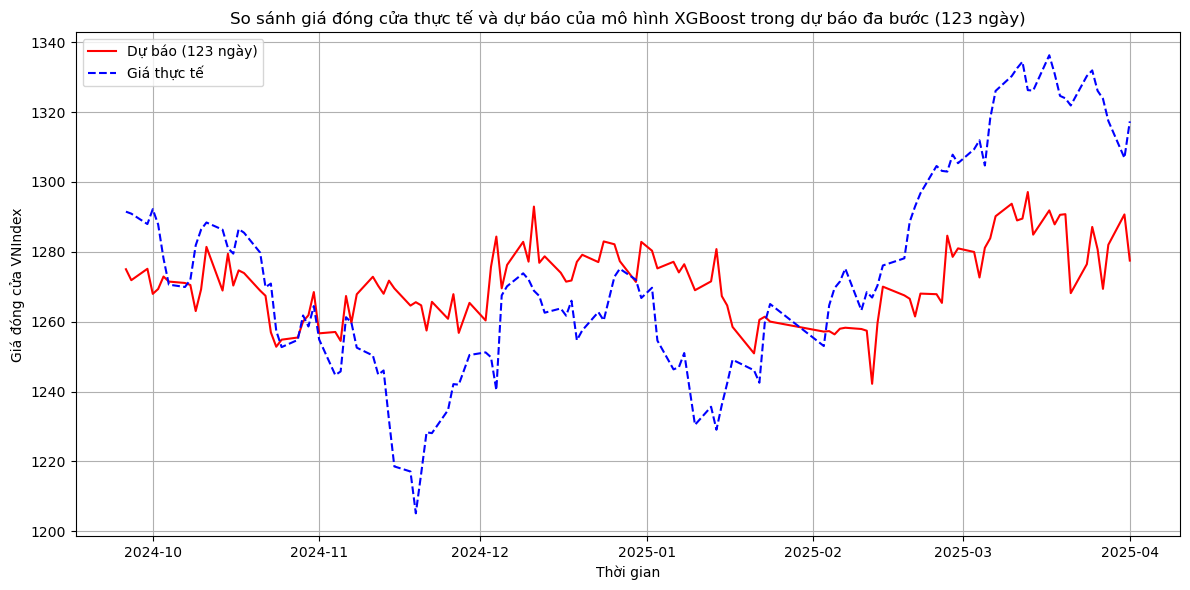

In [67]:
plt.figure(figsize=(12, 6))

# Vẽ dữ liệu dự báo và thực tế
plt.plot(df_test.index, pred_future, label='Dự báo (123 ngày)', color='red')
plt.plot(df_test.index, true_future, label='Giá thực tế', color='blue', linestyle='--')
#plt.plot(df.index, df['close'], label='Giá thực tế', color='blue', linestyle='--')

# Chú thích
plt.title('So sánh giá đóng cửa thực tế và dự báo của mô hình XGBoost trong dự báo đa bước (123 ngày)')
plt.xlabel('Thời gian')
plt.ylabel('Giá đóng cửa VNIndex')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()